# Write ESM25 Data to SeisBench-Format HDF5 Files

**Author:** Spina Cianetti and Dario Jozinović  
**License:** [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.html)  
This code is released under the GNU General Public License v3.0.



---

This notebook converts consolidated ESM25 HDF5 files into the **SeisBench bucket format**:

- Each bucket contains up to `BUCKET_SIZE` traces (default: 100)
- Traces are referenced via names formatted as `bucket{N}${i}`
- The output CSV metadata file includes a `trace_name` column for trace lookup in SeisBench

## Workflow Overview

1. **Setup** – imports and environment configuration
2. **Helper functions** – waveform/spectra reading, bucket creation, format writing
3. **Dataset configuration** – choose among `bad`, `good_cv`, `good_mp`, `spectra`
4. **Main loop** – bucket creation and HDF5 writing
5. **Verification** – inspection of the output files
6. **Optional visualization** – quick visual check of a sample bucket

---

## 1. Setup: Imports and Environment Configuration

Standard library imports needed throughout the notebook.

In [1]:
import os
import time

import h5py
import numpy as np
import pandas as pd

## 2. Helper Functions

### 2.1 Waveform Reading and Bucket Creation

The two functions below handle the core data reading logic:
- `create_waveform` reads a single trace from the source HDF5 file. All traces are assumed to already have a uniform shape, as padding was applied in the preceding notebook.
- `create_bucket` assembles a group of traces into a single 3-D NumPy array and assigns SeisBench-compatible trace names.

In [2]:
def create_waveform(wf_meta, h5_file, dataset):
    """Read a single waveform from the source HDF5 file.

    Traces are assumed to already have a uniform shape, as padding was applied
    in the preceding notebook. This function simply reads and returns the array.

    Args:
        wf_meta (pd.Series): a single row from the metadata DataFrame.
        h5_file (str): path to the source HDF5 file.
        dataset (str): dataset type identifier ('bad', 'good_cv', 'good_mp', 'spectra').

    Returns:
        np.ndarray: array with shape (n_comp, n_samples) as stored in the source file.
                    Returns None if the trace cannot be found.
    """
    VALID_DATASETS = {'bad', 'good_cv', 'good_mp', 'spectra'}
    if dataset not in VALID_DATASETS:
        raise ValueError(f"Unknown dataset type: {dataset}")

    # Spectra are stored in the 'spectra' group; waveforms in 'data'
    group_name = 'spectra' if dataset == 'spectra' else 'data'
    trace_name = wf_meta['trace_name_old']

    try:
        with h5py.File(h5_file, 'r') as f:
            data_grp = f[group_name]
            if trace_name not in data_grp:
                raise KeyError(f"Trace {trace_name} not found in group '{group_name}'")
            wfArr = data_grp[trace_name][()]
    except Exception as e:
        print(f"\u26a0 Trace {trace_name} could not be read: {e}")
        return None

    return np.asarray(wfArr, dtype=np.float32)


def create_bucket(bucketMeta, bucketIndex, h5_file, dataset):
    """Assemble a bucket of waveforms by reading from the source HDF5 file.

    A bucket groups up to BUCKET_SIZE traces into a single 3-D array,
    following the SeisBench bucket naming convention.
    Traces are assumed to already have a uniform shape (padding applied upstream).

    Args:
        bucketMeta (pd.DataFrame): metadata subset (max BUCKET_SIZE rows) for this bucket.
        bucketIndex (int): 1-based index of this bucket.
        h5_file (str): path to the source HDF5 file.
        dataset (str): dataset type identifier.

    Returns:
        tuple: (bucketArray, traceNamesList)
            - bucketArray:    np.ndarray with shape (N_rows, n_comp, n_samples)
            - traceNamesList: list of strings formatted as 'bucket{N}${i}'
    """
    bucketMeta = bucketMeta.reset_index(drop=True)
    wfNamesList = []
    wfBucket = []

    for k, row in bucketMeta.iterrows():
        # Assign SeisBench-compatible trace name: bucketN$i
        wfNamesList.append(f'bucket{bucketIndex}${k}')
        wf = create_waveform(row, h5_file, dataset)
        if wf is None:
            raise ValueError(f"Could not read trace at row {k} (bucket {bucketIndex})")
        wfBucket.append(wf)

    # Stack individual waveforms into a single 3-D array along the first axis
    wfBucket = np.stack(wfBucket, axis=0)
    return wfBucket, wfNamesList

### 2.2 Data Format Writing Functions

SeisBench expects a `data_format` group inside the HDF5 file, describing the component layout and physical units of the stored data.
The three functions below write the correct format metadata for each dataset type:
- **3-component** (cv acceleration: `bad` and `good_cv`)
- **9-component** (mp acc/vel/dis: `good_mp`)
- **6-component spectra** (mp acc/dis: `spectra`)

In [3]:
def _write_data_format(h5file, data_format_dict):
    """Internal helper: create or update the 'data_format' group in an HDF5 file.

    If a key already exists in the group it is deleted before being re-written,
    ensuring idempotent behaviour when appending to an existing file.

    Args:
        h5file: an HDF5 file object opened in write mode.
        data_format_dict (dict): dictionary of format metadata key-value pairs.

    Returns:
        dict: the dictionary that was written.
    """
    grp = h5file.require_group('data_format')
    for key, value in data_format_dict.items():
        if key in grp:
            del grp[key]  # Remove existing entry to allow overwrite
        grp.create_dataset(key, data=value)
    return data_format_dict


def add_data_format_info_3(h5file, data_in_counts=True):
    """Write the data format descriptor for 3-component datasets (cv acceleration).

    Used for 'bad' and 'good_cv' datasets. Component order: U, V, W axes.

    Args:
        h5file: an HDF5 file object opened in write mode.
        data_in_counts (bool): if True, data are raw counts; if False, restituted to physical units.
    """
    data_format = {
        'dimension_order': 'CW',  # C = components, W = waveform samples
        'component_order': ['acc_cv_u', 'acc_cv_v', 'acc_cv_w'],
        'measurement': 'acceleration',
        'instrument_response': 'not restituted' if data_in_counts else 'restituted',
        'unit': 'counts' if data_in_counts else 'cps2',
    }
    return _write_data_format(h5file, data_format)


def add_data_format_info_9(h5file, data_in_counts=True):
    """Write the data format descriptor for 9-component datasets (mp acc/vel/dis).

    Used for 'good_mp' dataset. Components are stacked as:
    3 acceleration + 3 velocity + 3 displacement, each along U, V, W axes.

    Args:
        h5file: an HDF5 file object opened in write mode.
        data_in_counts (bool): if True, data are raw counts; if False, restituted to physical units.
    """
    data_format = {
        'dimension_order': 'CW',
        'component_order': [
            'acc_mp_u', 'acc_mp_v', 'acc_mp_w',  # acceleration components
            'vel_mp_u', 'vel_mp_v', 'vel_mp_w',  # velocity components
            'dis_mp_u', 'dis_mp_v', 'dis_mp_w',  # displacement components
        ],
        'measurement': 'acceleration,velocity,displacement',
        'instrument_response': 'not restituted' if data_in_counts else 'restituted',
        'unit': 'counts' if data_in_counts else 'cps2/cps/c',
    }
    return _write_data_format(h5file, data_format)


def add_spectra_format_info(h5file, data_in_counts=True):
    """Write the data format descriptor for 6-component response spectra (mp acc/dis).

    Used for the 'spectra' dataset. Components are stacked as:
    3 acceleration spectra + 3 displacement spectra, each along U, V, W axes.

    Args:
        h5file: an HDF5 file object opened in write mode.
        data_in_counts (bool): if True, data are raw counts; if False, restituted to physical units.
    """
    data_format = {
        'dimension_order': 'CW',
        'component_order': [
            'acc_mp_u', 'acc_mp_v', 'acc_mp_w',  # acceleration spectral components
            'dis_mp_u', 'dis_mp_v', 'dis_mp_w',  # displacement spectral components
        ],
        'measurement': 'acceleration,displacement',
        'instrument_response': 'not restituted' if data_in_counts else 'restituted',
        'unit': 'counts' if data_in_counts else 'cps2/c',
    }
    return _write_data_format(h5file, data_format)

## 3. Dataset Configuration

Set the `DATASET` variable to select which type of data to process.
Also update `SOURCE_DIR` and `OUTPUT_BASE_DIR` to match your local paths.

| Value        | Source HDF5 file          | Waveform shape  | Description                                  |
|--------------|---------------------------|-----------------|----------------------------------------------|
| `'bad'`      | `waveforms_bad_cv.h5`          | (3, 84000)      | cv acceleration only (low-quality records)   |
| `'good_cv'`  | `waveforms_good_cv.h5`    | (3, 84000)      | cv acceleration (good quality)               |
| `'good_mp'`  | `waveforms_good_mp.h5`    | (9, 84000)      | mp acc/vel/dis (good quality)                |
| `'spectra'`  | `spectra_all.h5`          | (6, 105)        | acc/dis response spectra                     |

In [4]:
# ============================================================
# MAIN CONFIGURATION – edit these parameters before running
# ============================================================

# Root directory containing the consolidated ESM25 HDF5 source files
SOURCE_DIR = '/home/jovyan/shared/users/spina/ESM25/h5_all_v4/'

# Base output directory where SeisBench-format files will be saved
OUTPUT_BASE_DIR = '/home/jovyan/shared/users/spina/ESM25/dataset_final/'

# Dataset type to process: 'bad' | 'good_cv' | 'good_mp' | 'spectra'
DATASET = 'bad'

# Number of traces per bucket (SeisBench default is 1024; here we use 100)
BUCKET_SIZE = 100

# Set to False if data have already been restituted to physical units
DATA_IN_COUNTS = False

# ============================================================

# Dataset-specific configuration mapping
DATASET_CONFIG = {
    'bad': {
        'metadata_csv':  'metadata_bad_clean.csv',
        'source_h5':     os.path.join(SOURCE_DIR, 'waveforms_bad_cv.h5'),
        'output_subdir': 'bad',
        'format_func':   add_data_format_info_3,
        'has_x_axis':    False,
    },
    'good_cv': {
        'metadata_csv':  'metadata_final.csv',
        'source_h5':     os.path.join(SOURCE_DIR, 'waveforms_good_cv.h5'),
        'output_subdir': 'good_cv',
        'format_func':   add_data_format_info_3,
        'has_x_axis':    False,
    },
    'good_mp': {
        'metadata_csv':  'metadata_final.csv',
        'source_h5':     os.path.join(SOURCE_DIR, 'waveforms_good_mp.h5'),
        'output_subdir': 'good_mp',
        'format_func':   add_data_format_info_9,
        'has_x_axis':    False,
    },
    'spectra': {
        'metadata_csv':  'metadata_final.csv',
        'source_h5':     os.path.join(SOURCE_DIR, 'spectra_all.h5'),
        'output_subdir': 'spectra',
        'format_func':   add_spectra_format_info,
        'has_x_axis':    True,     # spectra datasets include a period x-axis
        'x_axis_name':   'Period',
    },
}

# Retrieve the config for the selected dataset and resolve the output path
cfg = DATASET_CONFIG[DATASET]
OUTPUT_DIR = os.path.join(OUTPUT_BASE_DIR, cfg['output_subdir'])

print(f"Selected dataset    : {DATASET}")
print(f"Source HDF5 file    : {cfg['source_h5']}")
print(f"Metadata CSV        : {cfg['metadata_csv']}")
print(f"Output directory    : {OUTPUT_DIR}")
print(f"Bucket size         : {BUCKET_SIZE}")

Selected dataset    : bad
Source HDF5 file    : /home/jovyan/shared/users/spina/ESM25/h5_all_v4/waveforms_bad_cv.h5
Metadata CSV        : metadata_bad_clean.csv
Output directory    : /home/jovyan/shared/users/spina/ESM25/dataset_final/bad
Bucket size         : 100


## 4. Load Metadata

Read the metadata CSV file associated with the selected dataset.
The existing `trace_name` column (referring to names in the *source* HDF5) is renamed to
`trace_name_old` so that it can be used as a lookup key without conflicting with the
new `trace_name` column that will be generated during bucket creation.

In [5]:
# Explicit dtype map for columns that should be read as strings
# (prevents pandas from interpreting channel codes such as '001' as integers)
DTYPE_MAP = {
    'station_code':           str,
    'station_network_code':   str,
    'station_channel_code':   str,
    'station_location_code':  str,
    'trace_u_channel_code':   str,
    'trace_v_channel_code':   str,
    'trace_w_channel_code':   str,
}

df_meta = pd.read_csv(
    cfg['metadata_csv'],
    low_memory=False,
    index_col=False,
    dtype=DTYPE_MAP,
)

# Rename existing trace_name to trace_name_old so it can be used as the source HDF5 key
if 'trace_name' in df_meta.columns:
    df_meta.rename(columns={'trace_name': 'trace_name_old'}, inplace=True)

print(f"Rows loaded         : {len(df_meta):,}")
print(f"Unique events       : {df_meta['source_esm_id'].nunique():,}")
print(f"Columns (first 8)   : {list(df_meta.columns[:8])} ...")
df_meta.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'metadata_bad_clean.csv'

## 5. Main Loop: Bucket Creation and HDF5 Writing

This is the core processing step. The metadata is split into chunks of `BUCKET_SIZE` rows;
for each chunk a bucket array is created and written to the output HDF5 file.

Trace names follow the SeisBench convention: `bucket{N}${i}`, where `N` is the 1-based
bucket number and `i` is the 0-based index of the trace within that bucket.

If a bucket fails, a NaN placeholder array is written and the error is logged to `errors.csv`.
At the end, the updated metadata (with the new `trace_name` column) is saved to `metadata.csv`.

In [6]:
start_time = time.time()
print(f"Processing started: {time.strftime('%Y-%m-%d %H:%M:%S')}")

# Create output directory if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
hdf_file_path = os.path.join(OUTPUT_DIR, 'waveforms.hdf5')

# Open the output HDF5 file in append mode if it already exists, otherwise create it
h5_file = h5py.File(hdf_file_path, 'a' if os.path.isfile(hdf_file_path) else 'w')
if 'data' not in h5_file:
    h5_file.create_group('data')  # SeisBench waveforms are stored under the 'data' group

errors = []            # Collect per-bucket error messages
trace_names_list = []  # Accumulate trace names for the metadata CSV
n_buckets = int(np.ceil(len(df_meta) / BUCKET_SIZE))
x_axis_saved = False   # Flag to avoid writing the x-axis more than once (spectra only)

print(f"Total buckets to create: {n_buckets}")

for i in range(n_buckets):
    # Slice the metadata for this bucket
    start_idx = i * BUCKET_SIZE
    end_idx   = min((i + 1) * BUCKET_SIZE, len(df_meta))
    bucket_meta = df_meta.iloc[start_idx:end_idx].reset_index(drop=True)

    try:
        # Build the bucket array and the corresponding trace names list
        bucket_array, bucket_trace_names = create_bucket(
            bucket_meta,
            i + 1,
            cfg['source_h5'],
            DATASET
        )

        trace_names_list.extend(bucket_trace_names)

        # Write the bucket to the HDF5 file (overwrite if already present)
        bucket_name = f'bucket{i+1}'
        if bucket_name in h5_file['data']:
            del h5_file['data'][bucket_name]
        h5_file['data'].create_dataset(bucket_name, data=bucket_array)

        # For spectra datasets, copy the period x-axis from the source file (once only)
        if cfg.get('has_x_axis') and not x_axis_saved:
            with h5py.File(cfg['source_h5'], 'r') as f_src:
                x_axis_name = cfg.get('x_axis_name', 'x_axis')
                if x_axis_name in f_src:
                    x_axis = f_src[x_axis_name][()]
                    if 'x_axis' not in h5_file['data']:
                        h5_file['data'].create_dataset('x_axis', data=x_axis)
                    x_axis_saved = True

    except Exception as e:
        # On error: log it and generate fallback trace names for the affected rows
        errors.append(f'Bucket {i+1}: {e}')
        print(f"\u26a0 Error in bucket {i+1}: {e}")

        # Generate fallback trace names so trace_names_list stays aligned with df_meta
        for k in range(len(bucket_meta)):
            trace_names_list.append(f'bucket{i+1}${k}')

# Sanity check: trace_names_list must have the same length as df_meta
if len(trace_names_list) != len(df_meta):
    missing = len(df_meta) - len(trace_names_list)
    print(f"\u26a0 WARNING: trace_names_list is {missing} names short. Filling with NA.")
    trace_names_list.extend([pd.NA] * missing)

# Attach the new trace names to the metadata and save the CSV
df_meta['trace_name'] = trace_names_list
df_meta.to_csv(os.path.join(OUTPUT_DIR, 'metadata.csv'), index=False)

# Save error log if any errors occurred
if errors:
    pd.DataFrame(errors, columns=['Error']).to_csv(
        os.path.join(OUTPUT_DIR, 'errors.csv'), index=False
    )
    print(f"\u26a0 {len(errors)} error(s) logged to errors.csv")

# Write the data_format metadata group and close the HDF5 file
cfg['format_func'](h5_file, DATA_IN_COUNTS)
h5_file.close()

elapsed = time.time() - start_time
print("=" * 60)
print(f"Processing completed in {elapsed:.2f} seconds")
print(f"HDF5 file written   : {hdf_file_path}")
print(f"Metadata CSV written: {os.path.join(OUTPUT_DIR, 'metadata.csv')}")
print(f"Buckets created     : {n_buckets}")
print(f"Total traces        : {len(trace_names_list):,}")

Processing started: 2026-02-23 09:21:57
Total buckets to create: 357
Processing completed in 68.87 seconds
HDF5 file written   : /home/jovyan/shared/users/spina/ESM25/dataset_2/bad/waveforms.hdf5
Metadata CSV written: /home/jovyan/shared/users/spina/ESM25/dataset_2/bad/metadata.csv
Buckets created     : 357
Total traces        : 35,627


## 6. Output Verification

Quick inspection of the generated SeisBench HDF5 file and metadata CSV to confirm
that the number of buckets, shapes, and trace names are as expected.

In [7]:
with h5py.File(hdf_file_path, 'r') as f:
    data_grp = f['data']
    buckets = [k for k in data_grp.keys() if k.startswith('bucket')]
    n_buckets_found = len(buckets)

    print(f"Buckets found in file : {n_buckets_found}")

    # Sample the first bucket to verify shape
    if n_buckets_found > 0:
        sample_bucket = buckets[0]
        sample_data = data_grp[sample_bucket]
        print(f"Shape of '{sample_bucket}': {sample_data.shape}")
        print(f"  (n_traces, n_comp, n_samples) = {sample_data.shape}")

    # Check for x_axis (spectra datasets only)
    if 'x_axis' in data_grp:
        x_axis = data_grp['x_axis'][()]
        print(f"x_axis shape          : {x_axis.shape}")

    # Verify the data_format group
    if 'data_format' in f:
        fmt_grp = f['data_format']
        comp_order = [c.decode() for c in fmt_grp['component_order'][()]]
        print(f"component_order       : {comp_order}")

# Verify the metadata CSV
df_check = pd.read_csv(os.path.join(OUTPUT_DIR, 'metadata.csv'), low_memory=False)
print(f"\nMetadata CSV rows     : {len(df_check):,}")
if 'trace_name' in df_check.columns:
    print(f"  Unique trace_names  : {df_check['trace_name'].nunique():,}")
    print(f"  Missing trace_names : {df_check['trace_name'].isna().sum()}")

Buckets found in file : 357
Shape of 'bucket1': (100, 3, 84000)
  (n_traces, n_comp, n_samples) = (100, 3, 84000)
component_order       : ['acc_cv_u', 'acc_cv_v', 'acc_cv_w']

Metadata CSV rows     : 35,627
  Unique trace_names  : 35,627
  Missing trace_names : 0


## 7. Optional: Visual Check of a Sample Bucket

Plot the first few traces from `bucket1` to visually inspect the stored waveforms.
Each component is shown on a separate subplot. Adjust `SAMPLE_BUCKET` and
`N_TRACES_TO_PLOT` as needed.

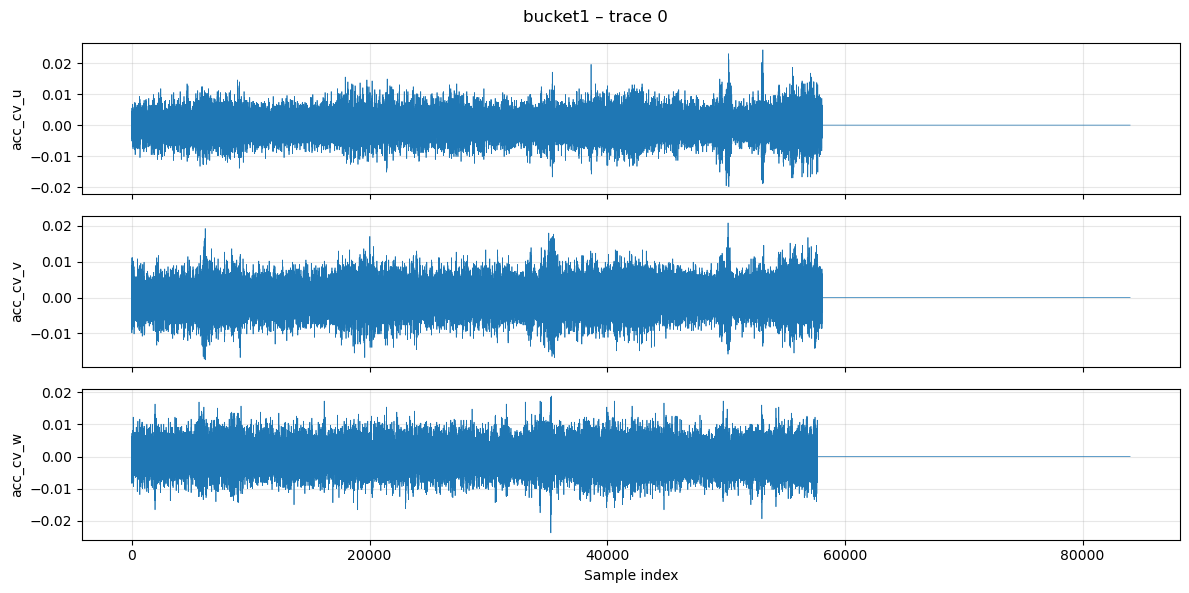

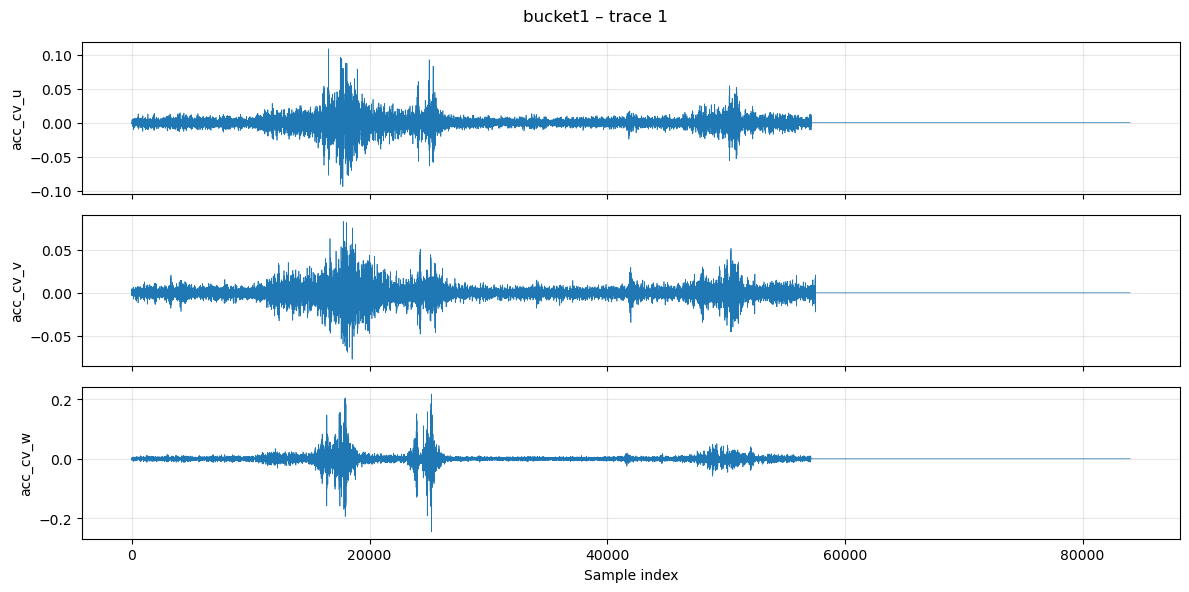

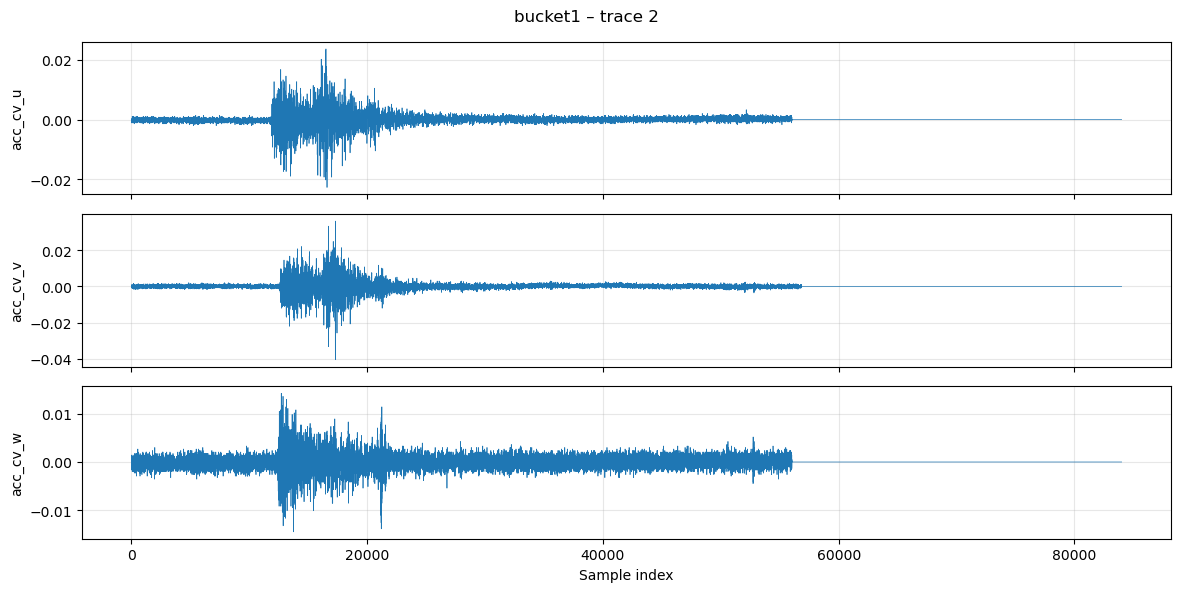

In [8]:
import matplotlib.pyplot as plt

SAMPLE_BUCKET    = 'bucket1'  # Name of the bucket to visualise
N_TRACES_TO_PLOT = 3          # Number of traces to plot from that bucket

with h5py.File(hdf_file_path, 'r') as f:
    if SAMPLE_BUCKET not in f['data']:
        print(f"Bucket '{SAMPLE_BUCKET}' not found in the HDF5 file.")
    else:
        # Load bucket data: shape (N_traces, n_comp, n_samples)
        data = f['data'][SAMPLE_BUCKET][()]
        comp_order = [c.decode() for c in f['data_format/component_order'][()]]

n_traces, n_comp, n_samples = data.shape
n_to_plot = min(N_TRACES_TO_PLOT, n_traces)

for t in range(n_to_plot):
    fig, axes = plt.subplots(n_comp, 1, figsize=(12, 2 * n_comp), sharex=True)
    if n_comp == 1:
        axes = [axes]

    for c in range(n_comp):
        axes[c].plot(data[t, c, :], linewidth=0.5)
        axes[c].set_ylabel(comp_order[c])
        axes[c].grid(alpha=0.3)

    axes[-1].set_xlabel('Sample index')
    fig.suptitle(f'{SAMPLE_BUCKET} – trace {t}')
    plt.tight_layout()
    plt.show()